In [2]:
import pickle

import numpy as np
import pyref.fitting as fit

from utils import models_root

In [3]:
with open(models_root / "xrr/dft/dft_en_offset_new.pkl", "rb") as f:
    dft_constraint = pickle.load(f)

print(dft_constraint)

________________________________________________________________________________


--Global Objective--
________________________________________________________________________________
Objective - 128510589874976
Dataset = <None>, 259 points
datapoints = 259
chi2 = 912.2937516192301
Weighted = True
Transform = Transform('logY')
________________________________________________________________________________
Parameters:    '_250.0'    
________________________________________________________________________________
Parameters: 'instrument parameters'
<Parameter:   'scale_s'   , value=1.07894 +/- 0.000159, bounds=[0.6, 1.4]>
<Parameter:   'scale_p'   , value=1.24357 +/- 0.000182, bounds=[0.6, 1.4]>
<Parameter:     'bkg'     , value=7.14339e-08  (fixed) , bounds=[-inf, inf]>
<Parameter:'dq - resolution', value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:'energy_offset', value=0.0170455 +/- 1.99e-06, bounds=[-1.0, 1.0], con

np.float64(52.82015071558566)

np.float64(69.01012516973368)

np.float64(43.81100461198054)

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/curvefitter.py:847: OptimizeWarning: Unknown solver options: worker
  res = minimize(cost, init_pars, **_min_kws)
-0.6949558483344307: : 433it [01:34,  4.57it/s]


________________________________________________________________________________
Parameters: 'Contamination_283.7'
________________________________________________________________________________
Parameters: 'Contamination_283.7_slab'
<Parameter:'Contamination_283.7_thick', value=4.02016 +/- 3.36 , bounds=[0.0, 35.0]>
<Parameter:'Contamination_283.7_rough', value=16.9293 +/- 0.768, bounds=[0.0, 25.0]>
<Parameter:'Contamination_283.7_density', value=0.577603 +/- 0.0609, bounds=[0.5, 1.8]>
<Parameter:'Contamination_283.7_rotation', value=0 +/- 7.6e-09, bounds=[0.0, 0.955316618124416]>
<Parameter:'Contamination_283.7_energy_offset', value=-0.06          , bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=-0.06 +/- 0.0304, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'

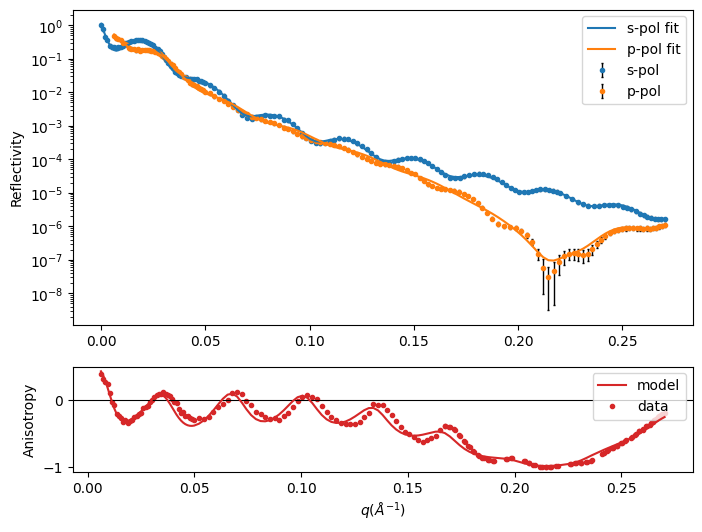

In [4]:
magic_angle = np.radians(54.73561031724)

for o in dft_constraint.objectives:
    if o.model.energy == 283.7:
        display(o.model.structure[1].sld.rotation.value * 180 / np.pi)
        display(o.model.structure[2].sld.rotation.value * 180 / np.pi)
        display(o.model.structure[3].sld.rotation.value * 180 / np.pi)
        # Constrain the rotation of the interface to be less than 54.73561031724 degrees
        # value to 0 degrees and remove lower bound on the thickness
        interface = o.model.structure[3]
        interface.sld.rotation.setp(value=54, bounds=(0, magic_angle))
        interface.sld.density.setp(bounds=(.5, 1.8))
        interface.thick.setp(value=0)
        interface.rough.setp(value=19)
        # Let's do the same for the surface interface
        surface = o.model.structure[1]
        surface.sld.rotation.setp(value=54, bounds=(0, np.pi/2))
        surface.sld.density.setp(bounds=(.5, 1.8))
        # surface.thick.setp(value=0)
        # surface.rough.setp(value=19)
        simple_fitter = fit.CurveFitter(o)
        simple_fitter.fit(options={"worker":-1})
        o.plot()
        print(interface)
        print(surface)
        break


<Axes: xlabel='zed / $\\AA$', ylabel='Index of refraction'>

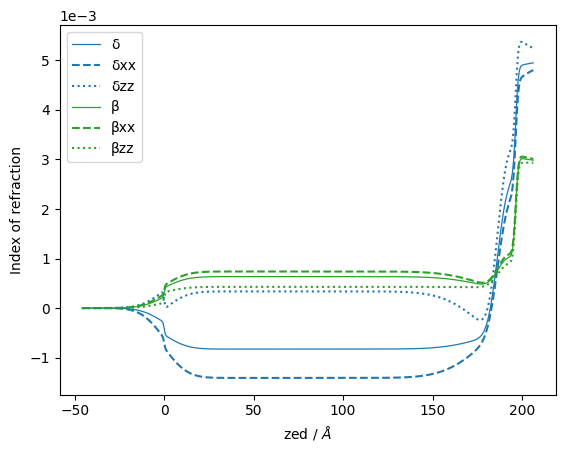

In [4]:
o.model.structure.plot()

In [5]:
print(o.model.structure)

________________________________________________________________________________
Structure: Monolayer_283.7
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_283.7' 
________________________________________________________________________________
Parameters: 'Vacuum_283.7_slab'
<Parameter:'Vacuum_283.7_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_energy_offset', value=-0.0624303          , bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=-0.0624303 +/- 0.0342, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'Surface_283.7_thick',

In [ ]:
test_fitter = fit.CurveFitter(dft_constraint)
test_fitter.fit(options={"worker":-1})

12.294784149504645: : 70it [15:36, 12.27s/it]

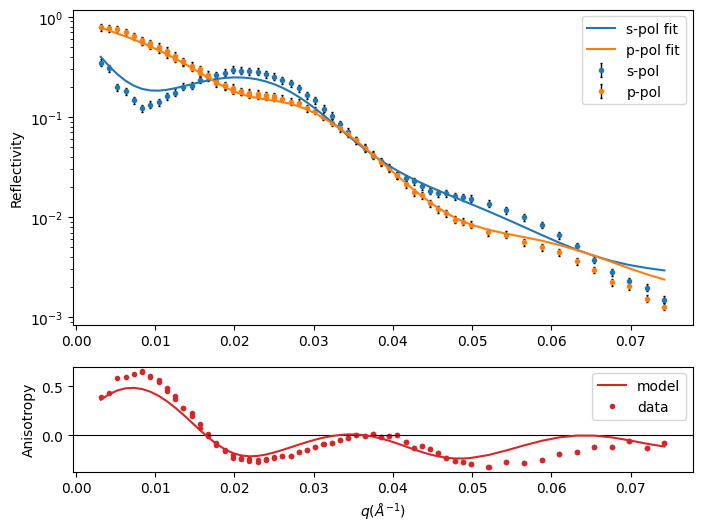

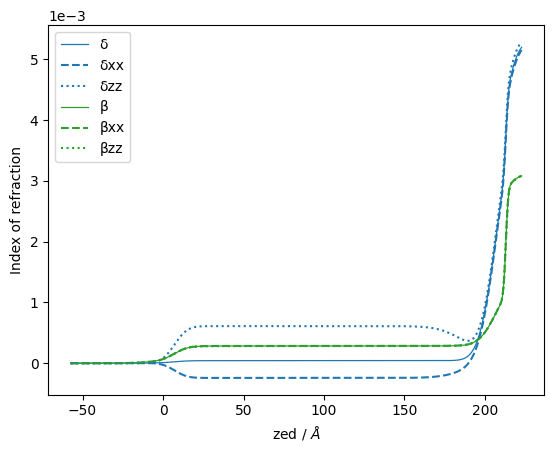

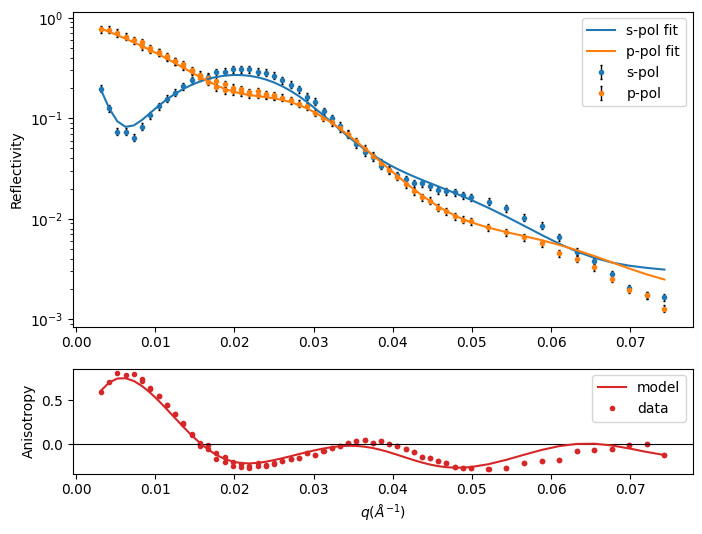

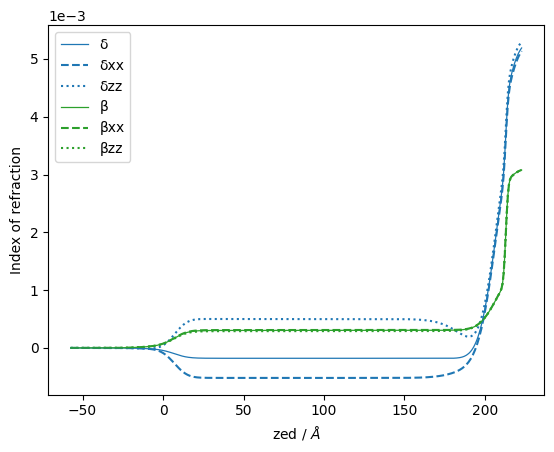

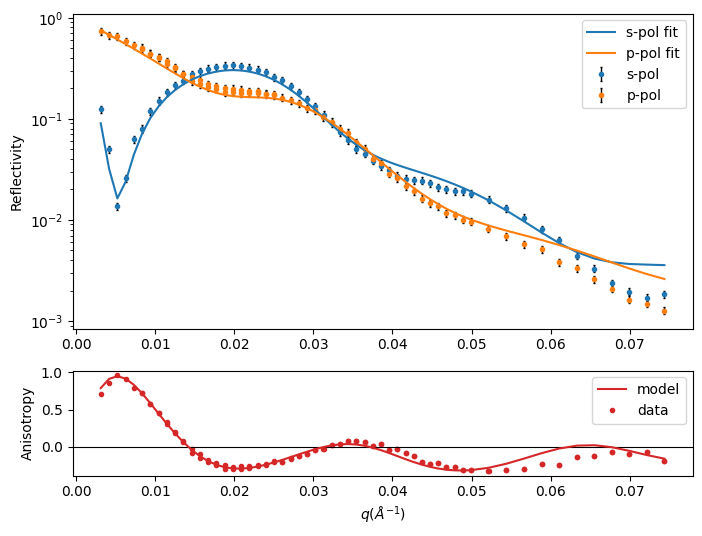

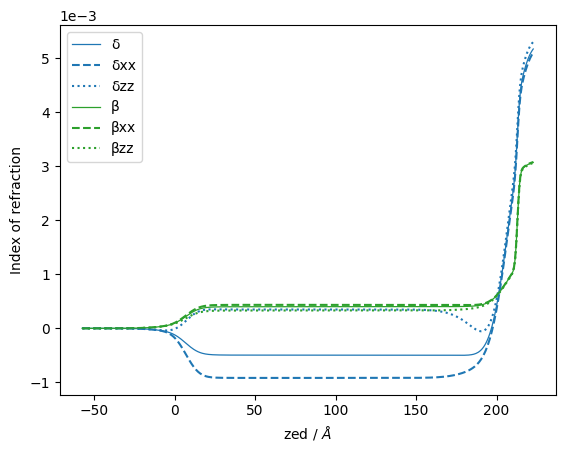

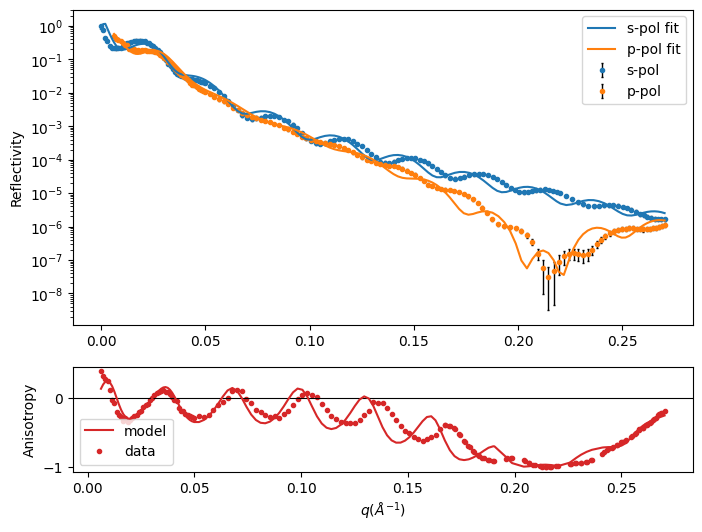

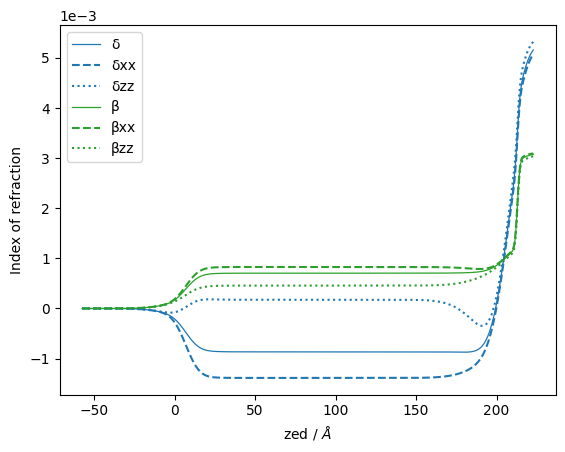

7.157663700119414 192.88473645839463 7.144105562929709
13.089369174809988 6.353264225585565 16.81191393780474
54.73561031724001 68.14230856157671 42.492953232206226


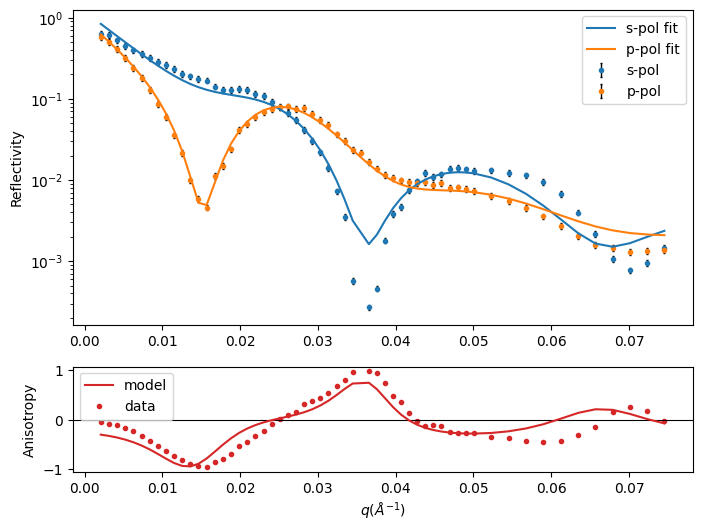

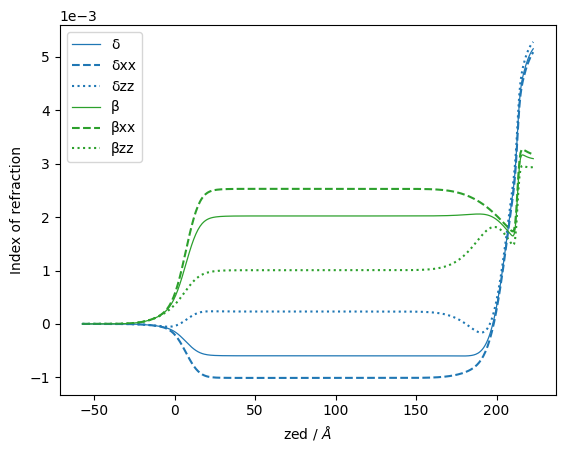

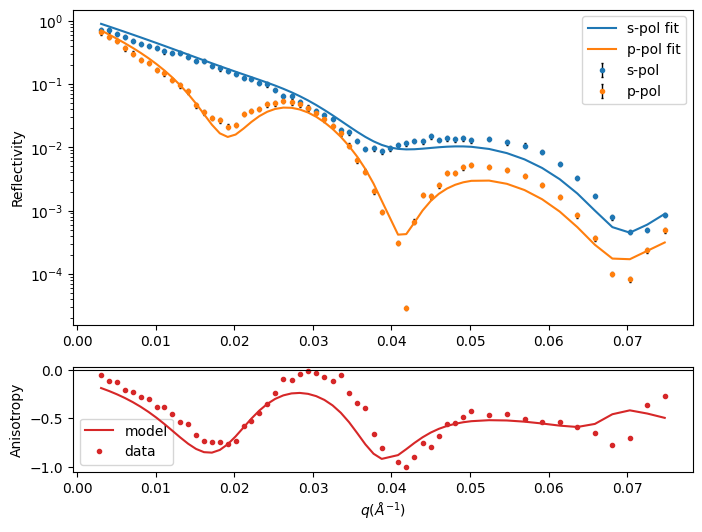

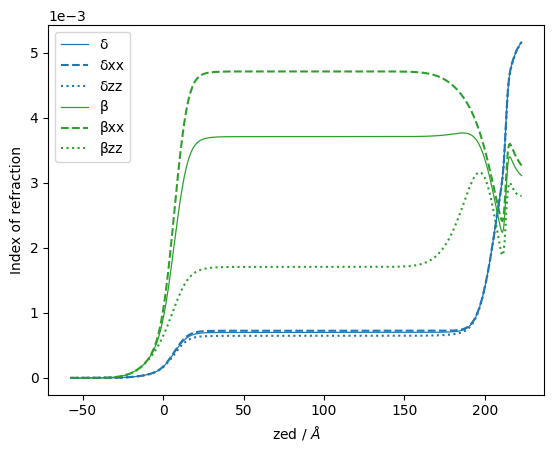

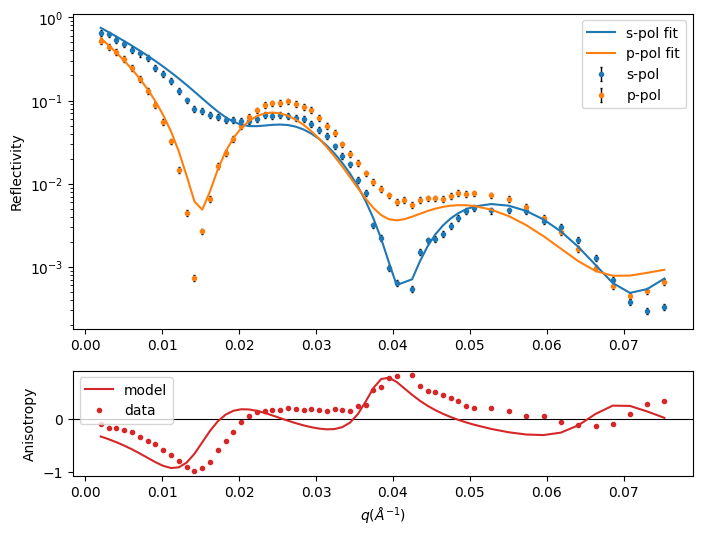

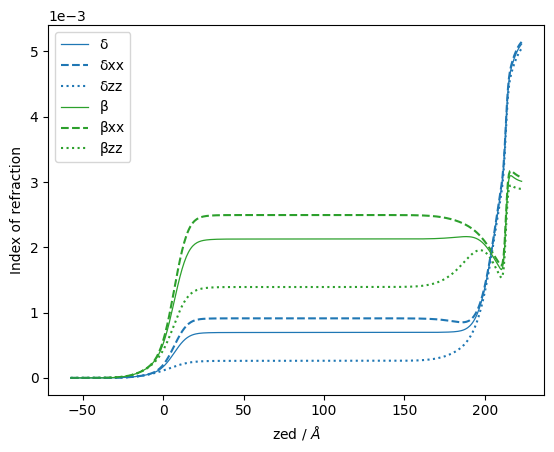

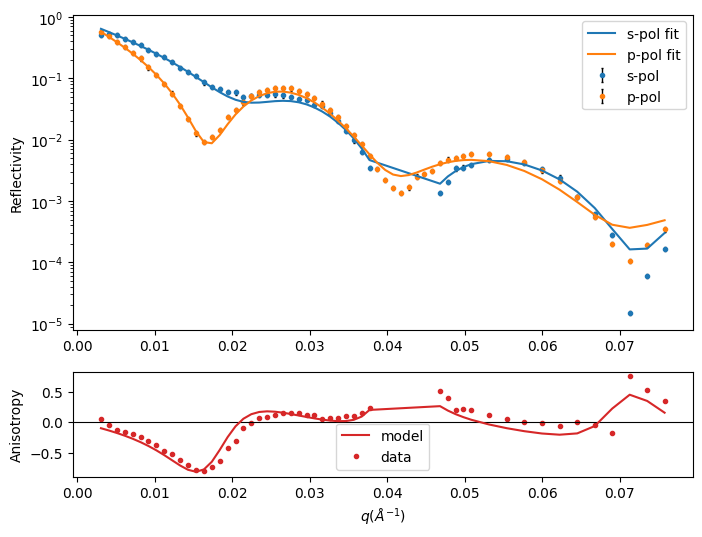

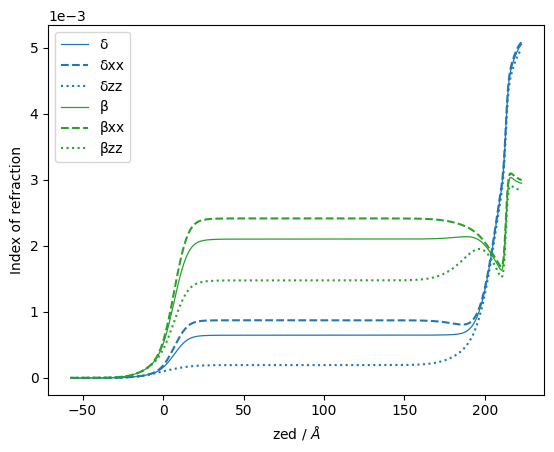

In [ ]:
import matplotlib.pyplot as plt

for o in test_fitter.objective.objectives:
    if o.model.energy >= 283:
        o.plot()
        plt.show()
        o.model.structure.plot()
        plt.show()
        if o.model.energy == 283.7:
            print(
                o.model.structure[1].thick.value,
                o.model.structure[2].thick.value,
                o.model.structure[3].thick.value,
            )
            print(
                o.model.structure[1].rough.value,
                o.model.structure[2].rough.value,
                o.model.structure[3].rough.value,
            )
            print(
                o.model.structure[1].sld.rotation.value * 180 / np.pi,
                o.model.structure[2].sld.rotation.value * 180 / np.pi,
                o.model.structure[3].sld.rotation.value * 180 / np.pi,
            )

In [33]:
with open(models_root / "xrr/dft/dft_en_offset_new.pkl", "wb") as f:
    pickle.dump(test_fitter.objective, f)
